# Lab 4: Reinforcement Learning - Part 1

In this lab, we aim to learn how to deal with practical reinforcement learning problems. 

We will cover both discrete RL approaches and function approximation.


The lab is divided into 2 parts.
- In **part 1**, we learn the basics of modelling a simple, finite states and action RL problem and how to solve it with Reinforcement Learning.
- In **part 2**, we will tackle a much more complicated problem, i.e., when the input is an image.

_Note_: Part 2 is in a separate notebook.


__Notes about structure__:
- When you need to make changes to code, it is marked with [# -> TODO: ... <-]
- Please answer the marked questions

***
## Modeling the Reinforcement Learning problem
***

In this part, we will model a simple finite state gridworld as a reinforcement learning problem, and we will solve it using SARSA and Q-Learning.

First of all, you will need to model the following problem:


### The Mountain Pass Gridworld

You are an explorer in the mountains. Your objective is to reach the top of the mountain, but the road is extremely dangerous and there are abysses everywhere were you can fall. To reach the top of the mountain there is a secret shortcut, that goes through an abyss with a bridge. You can activate the shortcut with a lever (by just reaching the state with the lever), which will create a bridge, but there is a probability p=0.025 at every step that the bridge will retract. The bridge will never retract if you are on top of it.

You must model the environment remembering this conditions
* If you fall in the abyss, or you reach the goal, the episode terminates.
* The reward function for this environment is -1 for each timestep, unless you fall into the abyss, where you will get a reward of -100, or if you reach the goal, where you get a reward of 100.
* At each time step you can move up, down, left or right. The action always succeeds.
* Use the map presented in the mountain_map.txt file here you have:
    * Impenetrable rocks marked as '#'
    * the abyss, marked as 'X'
    * The mountain top, marked as 'G'
    * The starting state, Marked as 'S'
    * Traversable area, marked as '.'
    * Traversable area with the secret lever '/'
    * The bridge shortcut, marked as '='
   
## Task 1.1 - Modeling the environment

Model the environment as a Finite Markov decision process. Parse the content of mountain_map.txt and transform this map into an MDP by providing:
- The reward function
- The transition probability kernel (as a transition matrix)
- The initial state distribution

All these quantities should be stored in numpy vectors.

These quantities are used by the FiniteMDP class, that you can find in [finite_mdp.py](./finite_mdp.py).

_Notes:_ When designing the environment be aware that
* You must model the Finite MDP state as an integer (not a tuple!)
* A state is a **valid** position of the agent + environment configuration (bridge deployed or not)
* The same agent position with the bridge deployed is not the same state as the one with bridge retracted.
* FiniteMDP expect state and action to be one dimensional numpy vectors



#### Creating the parse function
First we implement a parse function wich loads the map and creates a list of valid states

_note_: mark the activated lever in the map with a pipe ('|'). If the bridge is not active, it behaves like the abyss.

In [54]:
import numpy as np
import numpy.typing as npt

def parse_grid(grid: str) -> tuple[npt.NDArray, npt.NDArray]:
    """
    Parse the grid file:

    Args:
        grid: the path of the file containing the grid structure

    Returns:
        A numpy array containing the grid structure and a list of cells with the coordinates
    """
    lines = [] # list of lines of the grid map
    cell_list = [] # list of cells coordinates of relevant states

    valid_chars = ['#', '.', 'S', 'G', 'X', '/', '=']

    with open(grid, 'r') as f:
        for row_idx, line in enumerate(f.readlines()):
            lines.append(list(line.rstrip('\n')))
            col_idx = 0
            for character in line:
                # -> TODO: parse the character map and create the cell list with the coordinate of valid states <-
                if character in valid_chars:
                    if character != '#':
                        cell_list.append([0, row_idx, col_idx])
                        cell_list.append([1, row_idx, col_idx])
                    col_idx += 1
                elif character == '\n':
                    continue

    # Create the gridmap for active and inactive
    # -> TODO: create a greismap for valid and invalid states <-
    base = np.array(lines)
    inactive = base.copy()
    active = base.copy()
    
    inactive[inactive == '='] = 'X'
    active[active == '/'] = '|'

    grid_map = np.stack([inactive, active], axis=0)
    cell_list = np.array(cell_list, dtype=int)

    return grid_map, cell_list


#### Loading the map

Now we load the map from file and we create a list of valid cells

In [55]:
from debug_print import print_map

map_filename = 'mountain_map.txt'
grid_map, cell_list = parse_grid(map_filename)

print_map(grid_map)
print(f'There are {len(cell_list)} possible agent positions in this map')

##########  ##########  
#........#  #........#  
#...####.#  #...####.#  
#../XX...#  #..|XX...#  
#...X....#  #...=....#  
#SXXXX.G.#  #SXXXX.G.#  
##########  ##########  
There are 72 possible agent positions in this map


We can also visualize the map and the state numbers using matplotlib. To do so we will use the `visualize_state_numbers` function from [plot.py](./plot.py).

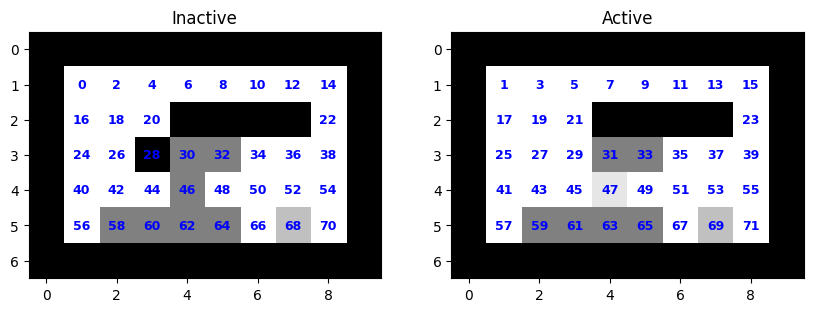

In [56]:
import matplotlib.pyplot as plt
from plot import visualize_state_numbers

visualize_state_numbers(grid_map, cell_list)
plt.show()

#### Compute the transition probability matrix
Using the map and the cell list, we compute the transition probability matrix.

_Note:_ You can see an example on how it is done for a similar, slightly simpler setup in [example_generator.py](./example_generator.py).


In [57]:
def compute_probabilities(
        grid_map: npt.NDArray,
        cell_list: npt.NDArray,
        prob: float
):
    """
    Compute the transition probability matrix.

    Args:
        grid_map: array containing the map
        cell_list: array of valid cells coordinates
        prob: probability of reverting back to the inactive bridge state

    Returns:
        The transition probability matrix
    """
    n_states = len(cell_list)
    p = np.zeros((n_states, 4, n_states))
    directions = [[-1, 0], [1, 0], [0, -1], [0, 1]]

    for i in range(len(cell_list)):
        state = cell_list[i]
        is_active = state[0] == 1

        if grid_map[tuple(state)] in ['S', '.', '/', '|', '=']: # the current state is not absorbing
            for a in range(len(directions)):
                # -> TODO: get the coordinates and position of new state <-
                new_rc = state[1:] + directions[a]
                target_same = np.array([state[0], new_rc[0], new_rc[1]])
                j_same = np.where((cell_list == target_same).all(axis=1))[0]
                new_char = grid_map[tuple(target_same)] if j_same.size > 0 else None

                if j_same.size > 0 and new_char != '/':   # -> TODO: handle the case you find the state and is not a lever <-
                     # -> TODO: handle the case is active/inactive and the door <-
                    j_dest = j_same[0]
                    # bridge can retract unless standing on it
                    if is_active and grid_map[tuple(state)] != '=':
                        j_inactive_dest = np.where((cell_list == np.array([0, new_rc[0], new_rc[1]])).all(axis=1))[0][0]
                        p[i, a, j_dest] = 1.0 - prob
                        p[i, a, j_inactive_dest] = prob
                    else:
                        p[i, a, j_dest] = 1.0
                elif j_same.size > 0: # -> TODO: handle the case the state is a lever <-
                    # stepping onto the lever activates the bridge: jump to the active layer twin
                    j_active_dest = np.where(
                        (cell_list == np.array([1, new_rc[0], new_rc[1]])).all(axis=1)
                    )[0][0]
                    p[i, a, j_active_dest] = 1.0
                else: # -> TODO: handle the wall (no state found) <-
                    # -> TODO:remember to handle active/inactive states <-
                    if is_active and grid_map[tuple(state)] != '=':
                        j_inactive_self = np.where(
                            (cell_list == np.array([0, state[1], state[2]])).all(axis=1)
                        )[0][0]
                        p[i, a, i] = 1.0 - prob
                        p[i, a, j_inactive_self] = prob
                    else:
                        p[i, a, i] = 1.0
        else: # The state is an absorbing state
            for a in range(len(directions)):
                p[i, a, i] = 1.

    return p

#### Compute the reward function matrix
Using the map and the cell list, we compute the reward function matrix


In [58]:
def compute_reward(
        grid_map: npt.NDArray,
        cell_list: npt.NDArray,
) -> npt.NDArray:
    """
    Compute the reward matrix.

    Args:
        grid_map: list containing the grid structure;
        cell_list: list of non-wall cells;

    Returns:
        The reward matrix.

    """
    n_states = len(cell_list)
    r = np.zeros((n_states, 4, n_states))

    def give_reward(target: str, reward: float):
        for x in np.argwhere(grid_map == target):
            j = np.where((cell_list == x).all(axis=1))[0]
            r[:, :, j] = reward

    # -> TODO: implement the reward function assigning the correct reward at each step <-
    # per-timestep cost
    r[:] = -1.0
    give_reward('G', 100.0)
    give_reward('X', -100.0)

    return r

#### Compute the initial state distribution
Using the map and the cell list, we compute the initial state distribution probability vector. 

_Note:_ we assign uniform distribution to every starting state.

In [59]:
def compute_mu(
        grid_map: npt.NDArray,
        cell_list: npt.NDArray,
) -> npt.NDArray:
    """
    Compute the initial state distribution.

    Args:
        grid_map: list containing the grid structure;
        cell_list: list of non-wall cells.

    Returns:
        The initial states distribution as a vector of probabilities.

    """
    # -> TODO: implement the initial state distribution function <-
    n_states = len(cell_list)
    mu = np.zeros(n_states)

    for x in np.argwhere(grid_map == 'S'):
        if x[0] == 0:
            j = np.where((cell_list == x).all(axis=1))[0]
            mu[j] = 1.0

    mu /= mu.sum()
    return mu

### Generate the Finite MDP

Now we will use the FiniteMDP class defined in [finite_mdp.py](./finite_mdp.py). This class represents an arbitrary Markov Chain.
Therefore, we need to define:
- the transition probability kernel P
- The reward function R
- the initial state distribution
- the discount factor

Additionally, as the computation is limited, and we cannot have arbitrarily long experiments, we truncate each episode after a number of steps. This is called horizon of the MDP.

In [60]:
from finite_mdp import FiniteMDP

gamma = 0.9
horizon = 200

p = compute_probabilities(grid_map, cell_list, prob=0.025)
r = compute_reward(grid_map, cell_list)
mu = compute_mu(grid_map, cell_list)

mdp = FiniteMDP(p, r, mu, gamma, horizon)

### Test the MDP

We will use  the functions `print_agent_state` and `print_agent_action` to debug our MDP.

You should create a loop that sample a uniform action and pints the agent state and the chosen action

In [61]:
from debug_print import print_agent_state, print_agent_action

state = mdp.reset()

print_agent_state(grid_map, cell_list, state)
for i in range(10):
    action = np.random.choice(4)
    print_agent_action(action)
    state, reward, absorbing = mdp.step(action)
    print_agent_state(grid_map, cell_list, state)
    if absorbing:
        break

##########
#........#
#...####.#
#../XX...#
#...X....#
#AXXXX.G.#
##########
Action sampled: left
##########
#........#
#...####.#
#../XX...#
#...X....#
#AXXXX.G.#
##########
Action sampled: right
##########
#........#
#...####.#
#../XX...#
#...X....#
#SAXXX.G.#
##########


## Task 1.2 - Implement the RL algorithms

Now we will implement RL algorithms to solve the Mountain Pass Gridworld.

We start by importing the Temporal Difference (TD) base class defined in [td_algorithm.py](./td_algorithm.py).

This class defines the basic interface of a TD learning algorithm for finite states and actions.


In [62]:
from td_algorithm import TD

Using this interface, we will implement the SARSA and Q-Learning algorithms.

But first, we need to define a policy.

### Epsilon Greedy Policy

In this assignment we will implement the Epsilon greedy policy.

Implement the `__call__` an `draw_action` methods.

In [63]:
class EpsGreedy:
    """
    Epsilon greedy policy.

    """
    def __init__(self, epsilon: float):
        """
        Constructor.

        Args:
            epsilon: the exploration coefficient. It indicates
                the probability of performing a random actions in the current
                step.

        """

        self._epsilon = epsilon
        self._q_function = None

    def set_q(self, q_function: npt.NDArray[np.float64]):
        """
        Args:
            q_function: the Q function to be used.
        """
        self._q_function = q_function

    def set_epsilon(self, epsilon: float):
        """
        Setter.

        Args:
            epsilon: the exploration coefficient. It indicates the
        """
        self._epsilon = epsilon

    def __call__(
            self,
            state: int,
            action: int,
    ) -> float:
        """
        Compute the probability of taking action in a certain state following
        the policy.

        Args:
            state: state where you want to evaluate the policy density;
            action: action where you want to evaluate the policy density;

        Returns:
            The probability of all actions following the policy in the given state if the list contains only the state,
            else the probability of the given action in the given state following the policy. If the action space is
            continuous, state and action must be provided

        """
        # -> TODO: compute the probability of an action under the epsilon greedy policy <-
        n_actions = self._q_function.shape[1]
        q_state = self._q_function[state]
        greedy_actions = np.where(q_state == q_state.max())[0]

        prob = self._epsilon / n_actions
        # greedy contribution, when multiple greedy actions
        if action in greedy_actions:
            prob += (1.0 - self._epsilon) / len(greedy_actions)
        return prob


    def draw_action(self, state: int):
        """
        Sample an action in ``state`` using the policy.

        Args:
            state: the state where the agent is.

        Returns:
            The action sampled from the policy and optionally the next policy state.

        """
        # -> TODO: implement the sampling of the epsilon greedy policy <-
        n_actions = self._q_function.shape[1]
        if np.random.rand() < self._epsilon:
            # random action, explore
            return np.random.choice(n_actions)
        # greedy action, exploit
        q_state = self._q_function[state]
        greedy_actions = np.where(q_state == q_state.max())[0]
        return np.random.choice(greedy_actions)

### SARSA

We now have to implement the SARSA algorithm class. You must use the `TD` abstract class to implement this algorithm.

Implement both the constructor and the update methods.

_Note:_ Remember that we need to apply the next action sampled in the update step to the next environment iteration!
use `self.next_action` to store this value. Beware! do not set a next action when you reach absorbing states!


In [64]:
class SARSA(TD):
    """
    SARSA algorithm.

    """
    def __init__(self, n_states, n_actions, gamma, policy, learning_rate):
        self._alpha = learning_rate
        super().__init__(n_states, n_actions, gamma, policy)

    def update(self, state, action, reward, next_state, absorbing):
        # -> TODO: implement the SARSA update, remember to set the next action! <-
        if absorbing:
            # die or win
            target = reward
        else:
            next_action = self.policy.draw_action(next_state)
            target = reward + self.gamma * self.Q[next_state, next_action]
            # store the action so next environment step uses it
            self.next_action = next_action

        self.Q[state, action] += self._alpha * (target - self.Q[state, action])

### Q-Learning

We now have to implement the Q-learning algorithm class. You must use the `TD` abstract class to implement this algorithm.

Implement both the constructor and the update methods.

In [65]:
class Q_learning(TD):
    """
    Q-Learning algorithm.

    """
    def __init__(self, n_states, n_actions, gamma, policy, learning_rate):
        self._alpha = learning_rate
        super().__init__(n_states, n_actions, gamma, policy)

    def update(self, state, action, reward, next_state, absorbing):
        # -> TODO: implement the Q-Learning update <-
        if absorbing:
            target = reward
        else:
            # best greedy action, not necessarily the one that will be taken
            target = reward + self.gamma * self.Q[next_state].max()

        self.Q[state, action] += self._alpha * (target - self.Q[state, action])

## Task 1.3 - Implement a Reinforcement Learning loop

Now that we have the algorithm, we can implement the reinforcement learning loop. We train in epochs, each epoch is composed of some steps of learning and some episodes of training.
To simplify this implementation we will implement each component as a separate function.

_Note_: an episode may end either because we reach an absorbing state, or because we truncate the episode due to the fact that we reached the horizon, i.e. a timestep limit for the episodes, introduced for computational reasons.

#### Learning steps function

This function should perform `n_steps` learning steps on the mdp and handle properly the resetting of the environment.

Implement the missing parts of the function.

In [66]:
def learn_steps(mdp, agent, n_steps: int):
    """
    Function to run a Reinforcement Learning agent for a number of learning steps in an environment.

    Args:
        mdp: the markov decision process;
        agent: the agent;
        n_steps: the number of learning steps to run.

    """
    last = True
    state = None
    episodes_steps = 0

    # Learning steps
    for t in range(n_steps):

        # Handle reset state
        if last:
            # -> TODO: implement reset <-
            state = mdp.reset()
            agent.reset()
            episodes_steps = 0
            last = False

        # Single learning step
        # -> TODO: implement learning for one step: take an action, apply in the MDP and update the agent <-
        action = agent.draw_action(state)
        next_state, reward, absorbing = mdp.step(action)
        agent.update(state, action, reward, next_state, absorbing)
        episodes_steps += 1

        # Check if episode is complete or not
        if absorbing or episodes_steps >= mdp.horizon:  # -> TODO: implement the absorbing check <-
            last = True

        # Update your current state
        state = next_state

#### Test episodes

The `test_episode` function should run a single test episode in the MDP. A test episode only calls the policy without performing any learning.

In [67]:
def test_episode(mdp, agent, render=False):
    """
    Function to test the performance of the agent in the environment for a single episode.

    Args:
        mdp: the markov decision process;
        agent: the agent;
        render: whether print debug information or not.

    Returns:
        The expected discounted return J, and a flag checking if the task has been solved.

    """
    J = 0

    state = mdp.reset()
    agent.reset()

    if render:
        print_agent_state(grid_map, cell_list, state)

    next_state = state
    for t in range(mdp.horizon):
        # -> TODO: implement the single step in the environment, with no learning! <-
        # 1 step
        action = agent.draw_action(state)
        next_state, reward, absorbing = mdp.step(action)

        # -> TODO: update current J properly <-
        J += (mdp.gamma ** t) * reward

        if render:
            print_agent_action(action)
            print_agent_state(grid_map, cell_list, next_state)
            print(f'Next state: {next_state}')
            print(f'Reward: {reward}')

        # break if absorbing state is reached
        if absorbing:
            break

        state = next_state

    # Check if the episode has reached the goal
    # -> TODO: compute the success flag <-
    is_success = grid_map[tuple(cell_list[next_state])] == 'G'

    return J, is_success

The `test_episodes` This function should run `n_episodes` tests episodes in the environment and collect the expected discounted return and the success rate for the task.

Complete the code where is missing.


In [68]:
def test_episodes(mdp, agent, n_episodes: int, render=False):
    """
    Function to test the performance of the agent in the environment.

    Args:
        mdp: the markov decision process to use;
        agent: the agent;
        n_episodes: number of test episodes;
        render: whether to call the rendering functionality or not.

    Returns:
        The expected discounted return J and the success rate for the test episodes.

    """
    J_list = list()
    success_list = list()

    for ep in range(n_episodes):
        # -> TODO: test one episode and store results <-
        J, is_success = test_episode(mdp, agent, render)
        J_list.append(J)
        success_list.append(is_success)

    # -> TODO: compute the average metrics <-
    J_ep = np.mean(J_list)
    success_rate = np.mean(success_list)

    return J_ep, success_rate


#### Testing the RL loop

we will use the TestAgent from [test_agent.py](./test_agent.py).

This agent reads the policy from the keyboard using the "wasd" keys such that you can control the agent in the environment.

_Note_: Set the `keyboard_test` flag to `True` to enable this test, or to `False` to disable it.

In [69]:
from test_agent import TestAgent

keyboard_test = False

if keyboard_test:
    test_agent = TestAgent()
    print('Testing environment with keyboard')
    test_episode(mdp, test_agent, render=True)
    input('Press enter to continue...')


### The RL Experiment

Now we have everything in place to implement the `experiment` function. This function represent a single RL experiment.
It performs `n_epochs` of training consisting in:
- some learning steps in the environment
- some episodes evaluation
- logging of the performance metrics over each epoch.

It must create the policy, the agent and run the RL loop. In the loop results must be collected and returned as a python dictionary.

You must log at every epoch of learning:

- `J`, the expected discounted return of the epsilon greedy policy
- `success_rate`, the success rate of the epsilon greedy policy
- `J_det`, the expected discounted return of the greedy policy (set epsilon to zero!)
- `success_rate_det`, the success rate of the greedy policy
- `Q`, the Q-Function of the agent

In [70]:
def experiment(algorithm, epsilon: float, learning_rate: float, n_epochs: int, n_steps: int, n_episodes_test: int, verbose=False):
    """
    Function to run a single RL experiment.

    Args:
        algorithm: The algorithm to use;
        epsilon: the epsilon parameter of the epsilon greedy policy;
        learning_rate: the learning rate for the algorithm;
        n_epochs: the number of training epochs;
        n_steps: the number of training steps per epoch;
        n_episodes_test: the number of test episodes;
        verbose: whether to print the info at each step or not.

    Returns:
        A dictionary containing the evaluation results.

    """
    # create policy
    policy = EpsGreedy(epsilon)

    # create agent
    agent = algorithm(mdp.n_states, mdp.n_actions, mdp.gamma, policy, learning_rate)

    J_list = list()
    J_det_list = list()
    success_list = list()
    success_det_list = list()


    # Learning epochs
    for epoch in range(n_epochs):
        if verbose:
            print(f'Epoch: {epoch}')
        # Training steps
        learn_steps(mdp, agent, n_steps)

        # Evaluation of the policy
        J_ep, success_rate = test_episodes(mdp, agent, n_episodes_test)


        # Evaluation of the deterministic policy
        # -> TODO: implement a deterministic evaluation of the policy <-
        policy.set_epsilon(0.0)
        J_ep_det, success_rate_det = test_episodes(mdp, agent, n_episodes_test)
        # -> TODO: remember to reset the exploration back to the normal amount! <-
        policy.set_epsilon(epsilon)

        if verbose:
            print(f'J: {J_ep}\t J_det: {J_ep_det}\t '
                  f'success_rate: {success_rate}\t success_rate_det: {success_rate_det}')

        J_list.append(J_ep)
        J_det_list.append(J_ep_det)
        success_list.append(success_rate)
        success_det_list.append(success_rate_det)

    results = dict(
        J=np.array(J_list),
        J_det=np.array(J_det_list),
        success_rate=np.array(success_list),
        success_rate_det=np.array(success_det_list),
        Q=agent.Q
    )

    return results

### Testing the experiment

Here we test a learning run with SARSA and Q-Learning in the environment we generated

In [76]:
n_epochs = 100
n_steps = 1000
n_episodes_test = 25
np.random.seed(0)

algs_and_params = [
    # -> TODO: Tune learnming rates and epsilon <-
    (SARSA, {'learning_rate': 0.2, 'epsilon': 0.2}),
    (Q_learning, {'learning_rate': 0.2, 'epsilon': 0.2}),
]

J_alg = dict()
success_alg = dict()
J_det_alg = dict()
success_det_alg = dict()
Q_alg = dict()

for algorithm, parameters in algs_and_params:
    alg_name = algorithm.__name__
    print(f'Running the {alg_name} algorithm')

    J_alg[alg_name] = list()
    success_alg[alg_name] = list()

    # get parameters from dictionary
    epsilon = parameters['epsilon']
    learning_rate = parameters['learning_rate']

    results = experiment(algorithm, epsilon, learning_rate, n_epochs, n_steps, n_episodes_test, verbose=True)

    J_alg[alg_name] = results['J']
    J_det_alg[alg_name] = results['J_det']
    success_alg[alg_name] = results['success_rate']
    success_det_alg[alg_name] = results['success_rate_det']
    Q_alg[alg_name] = results['Q']


Running the SARSA algorithm
Epoch: 0
J: -26.831091327379358	 J_det: -9.999999992944925	 success_rate: 0.0	 success_rate_det: 0.0
Epoch: 1
J: -19.718857384558568	 J_det: -9.999999992944925	 success_rate: 0.2	 success_rate_det: 0.0
Epoch: 2
J: -9.922614114644434	 J_det: 12.648024530411398	 success_rate: 0.8	 success_rate_det: 1.0
Epoch: 3
J: 3.2934157892532903	 J_det: 12.648024530411398	 success_rate: 0.96	 success_rate_det: 1.0
Epoch: 4
J: -6.831221043518465	 J_det: 12.648024530411398	 success_rate: 0.88	 success_rate_det: 1.0
Epoch: 5
J: 5.311793858972902	 J_det: 12.648024530411398	 success_rate: 1.0	 success_rate_det: 1.0
Epoch: 6
J: -3.524214735822251	 J_det: 12.648024530411398	 success_rate: 0.88	 success_rate_det: 1.0
Epoch: 7
J: 1.6209789550123945	 J_det: 12.648024530411398	 success_rate: 0.96	 success_rate_det: 1.0
Epoch: 8
J: -2.8188165514770906	 J_det: 12.648024530411398	 success_rate: 0.92	 success_rate_det: 1.0
Epoch: 9
J: -10.387951060669133	 J_det: 12.648024530411398	 succe

### Visualizing the learning metrics

Now we can visualize the learning metric of the RL learning run. what do you observe?

/var/folders/m_/xr9qzcjs7hj9w95lwkjsw9900000gn/T/ipykernel_42845/339696073.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)
/var/folders/m_/xr9qzcjs7hj9w95lwkjsw9900000gn/T/ipykernel_42845/339696073.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)
/var/folders/m_/xr9qzcjs7hj9w95lwkjsw9900000gn/T/ipykernel_42845/339696073.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False

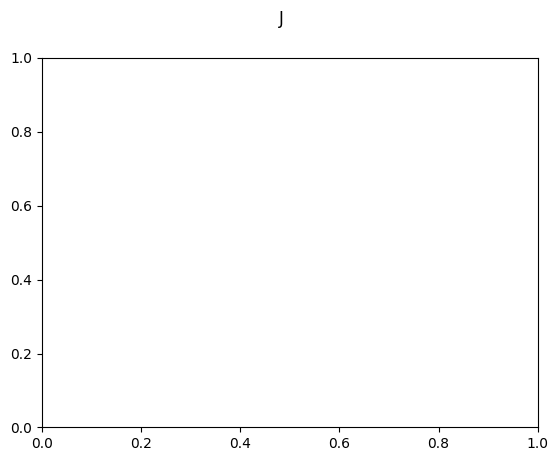

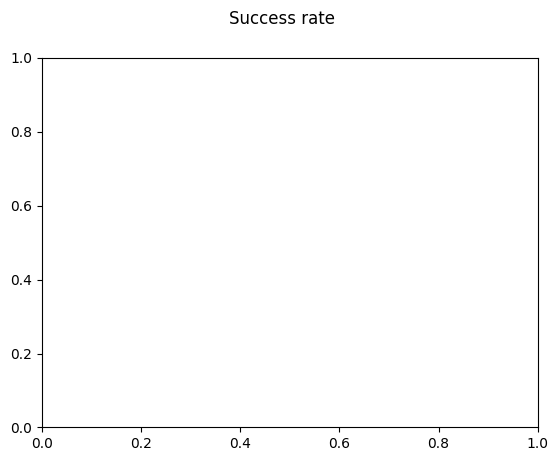

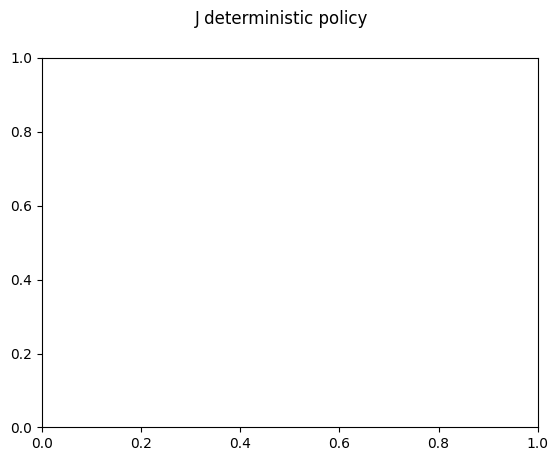

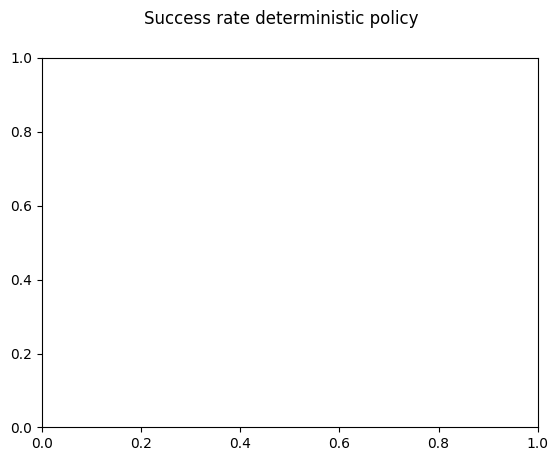

In [77]:
import matplotlib.pyplot as plt

plt.figure()
plt.suptitle('J')
# -> TODO: generate plot for J <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('Success rate')
# -> TODO: generate plot for success rate <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('J deterministic policy')
# -> TODO: generate plot for the deterministic J <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('Success rate deterministic policy')
# -> TODO: generate plot for the success rate <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.show()

#### Visualizing the policy and the value function

Now we can visualize the policy and the value function. What do you observe in the two cases? can you explain why you get such behavior?


In [73]:
from plot import visualize_value, visualize_policy

# Plot value function
for alg, Q in Q_alg.items():
    value_deterministic = _ # -> TODO: compute the value function of the greedy policy <-
    visualize_value(value_deterministic, grid_map, cell_list, 'Value function - ' + alg)

IndexError: string index out of range

In [ ]:
# Plot deterministic policy
for alg, Q in Q_alg.items():
    policy_max = _ # -> TODO: compute the greedy action <-
    visualize_policy(policy_max, grid_map, cell_list, 'Greedy policy - ' + alg)

plt.show()

## Task 1.4 - Full RL experiment

As the reinforcement Learning loop is stochastic, we need to run multiple random seed to get a statistically significant result.

We will repeat the experiment we run in the previous iteration, but running multiple seeds for each algorithm. Implement a loop that takes care of running the experiment for each algorithm and 10 different seeds.

In [ ]:
from tqdm.notebook import trange
n_seeds = 10

J_alg = dict()
J_det_alg = dict()
success_alg = dict()
success_det_alg = dict()

for algorithm, parameters in algs_and_params:
    alg_name = algorithm.__name__
    print(f'Running the {alg_name} algorithm' )
    J_alg[alg_name] = list()
    J_det_alg[alg_name] = list()
    success_alg[alg_name] = list()
    success_det_alg[alg_name] = list()

    for seed in trange(n_seeds):
        np.random.seed(seed)

        results =  experiment(algorithm, epsilon, learning_rate, n_epochs, n_steps, n_episodes_test)

        J_alg[alg_name].append(results['J'])
        J_det_alg[alg_name].append(results['J_det'])
        success_alg[alg_name].append(results['success_rate'])
        success_det_alg[alg_name].append(results['success_rate_det'])

### Printing the results

We now have the results of the RL loop. We will need to print the average metric and the 95% confidence interval.

To obtain this, we can use the `plot_mean_conf` function from the [plot.py](./plot.py) file.

In [ ]:
from plot import plot_mean_conf

plt.figure()
plt.suptitle('J')
# -> TODO: generate the plots for J <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('J Deterministic policy')
# -> TODO: generate the plots for deterministic J <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('Success rate')
# -> TODO: generate the plots for success rate <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.figure()
plt.suptitle('Success rate deterministic policy')
# -> TODO: generate the plots for success rate of teh deterministic policy <-
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.show()
